In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["PATH"] = "/mnt/lustre-grete/usr/u12045/projects/LLAVA-Med/envs/lerobot/bin:" + os.environ.get("PATH", "")
os.environ["HF_HOME"] = "/mnt/lustre-grete/usr/u12045/vla/hf_cache"
os.environ["TMPDIR"] = "/mnt/lustre-grete/usr/u12045/vla/cache"
os.environ["PYTHONPATH"] = "/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid:" + os.environ.get("PYTHONPATH", "")
import sys
sys.path.insert(0, "/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid")

import logging
import time
from contextlib import nullcontext
from pprint import pformat
from typing import Any

import torch
from termcolor import colored
from torch.amp import GradScaler
from torch.optim import Optimizer

from lerobot.common.datasets.factory import make_dataset
from lerobot.common.datasets.sampler import EpisodeAwareSampler
from lerobot.common.datasets.utils import cycle
from lerobot.common.envs.factory import make_env
from lerobot.common.optim.factory import make_optimizer_and_scheduler
from lerobot.common.policies.factory import make_policy
from lerobot.common.policies.pretrained import PreTrainedPolicy
from lerobot.common.policies.utils import get_device_from_parameters
from lerobot.common.utils.logging_utils import AverageMeter, MetricsTracker
from lerobot.common.utils.random_utils import set_seed
from lerobot.common.utils.train_utils import (
    get_step_checkpoint_dir,
    get_step_identifier,
    load_training_state,
    save_checkpoint,
    update_last_checkpoint,
)
from lerobot.common.utils.utils import (
    format_big_number,
    get_safe_torch_device,
    has_method,
    init_logging,
)
from lerobot.common.utils.wandb_utils import WandBLogger
from lerobot.configs import parser
from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.eval import eval_policy
from lerobot.common.constants import ACTION, OBS_STATE

import json
from dotenv import load_dotenv
load_dotenv()


%load_ext autoreload
%autoreload 2

In [2]:
init_logging()

In [88]:
# path 10
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_goal_noops_10/libero_goal_mask_depth_noops_lerobot'  # ok 
# REPO_ID ='/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_object_noops_10/libero_object_mask_depth_noops_lerobot' # ok
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_spatial_noops_10/libero_spatial_mask_depth_noops_lerobot' # ok
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_10_noops_10/libero_10_mask_depth_noops_lerobot' #

# path 40 
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_goal_noops_40/libero_goal_mask_depth_noops_lerobot' # ok
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_object_noops_40/libero_object_mask_depth_noops_lerobot' # ok
REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_spatial_noops_40/libero_spatial_mask_depth_noops_lerobot' # 
# REPO_ID ='/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_10_noops_40/libero_10_mask_depth_noops_lerobot' #

# path 100
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_goal_noops/libero_goal_mask_depth_noops_lerobot' #
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_object_noops/libero_object_mask_depth_noops_lerobot' #
# REPO_ID = '/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_spatial_noops/libero_spatial_mask_depth_noops_lerobot' # 
# REPO_ID ='/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_10_noops_40/libero_10_mask_depth_noops_lerobot' #

In [89]:
from lerobot.configs.policies import PreTrainedConfig
from lerobot.configs.default import DatasetConfig, EvalConfig, WandBConfig
from lerobot.common.datasets.transforms import ImageTransformsConfig

with open("../configs/fractal_config/default.json") as f:
    data = json.load(f)
# /mnt/lustre-grete/usr/u12045/vla/hf_cache/lerobot/binhng/libero_spatial_mask_debug_noops_lerobot
cfg = TrainPipelineConfig(
    policy=PreTrainedConfig.from_pretrained("lerobot/pi0"),
    dataset=DatasetConfig(
        # repo_id="/mnt/lustre-grete/usr/u12045/vla/hf_cache/lerobot/binhng/libero_10_mask_debug_noops_lerobot",
        repo_id = REPO_ID,
        image_transforms=ImageTransformsConfig.from_dict(data["dataset"]['image_transforms']),
    ),
    wandb=WandBConfig(
        project="lerobot",
        entity="lerobot",
    ),
)
cfg.validate()

In [90]:
cfg.dataset.image_transforms.image_tfs['crop_resize']

ImageTransformConfig(weight=1, type='RandomResizedCrop', kwargs={'size': [256, 320], 'ratio': [1, 1], 'scale': [0.9, 0.95]})

In [91]:
cfg.policy.chunk_size = 10
cfg.policy.n_action_steps = 10
cfg.batch_size = 1
cfg.wandb.enable = False
cfg.dataset.image_transforms.enable = True
cfg.log_freq = 20
cfg.num_steps = 2

In [92]:
if cfg.wandb.enable and cfg.wandb.project:
    wandb_logger = WandBLogger(cfg)
else:
    wandb_logger = None
    logging.info(colored("Logs will be saved locally.", "yellow", attrs=["bold"]))

if cfg.seed is not None:
    set_seed(cfg.seed)

device = get_safe_torch_device(cfg.policy.device, log=True)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

logging.info("Creating dataset")
dataset = make_dataset(cfg)

INFO 2025-07-19 10:43:12 2197283937.py:5 Logs will be saved locally.
INFO 2025-07-19 10:43:12 197283937.py:14 Creating dataset


Resolving data files:   0%|          | 0/200 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [93]:
if hasattr(cfg.policy, "drop_n_last_frames"):
    shuffle = False
    sampler = EpisodeAwareSampler(
        dataset.episode_data_index,
        drop_n_last_frames=cfg.policy.drop_n_last_frames,
        shuffle=True,
    )
else:
    shuffle = True
    sampler = None

dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=10,#cfg.num_workers,
    batch_size=32,
    shuffle=shuffle,
    sampler=sampler,
    pin_memory=device.type != "cpu",
    drop_last=False,
)
dl_iter = iter(dataloader)

this video path causes error:  /mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_spatial_noops_40/libero_spatial_mask_depth_noops_lerobot/videos/chunk-000/observation.images.wrist_depth/episode_000020.mp4
this video path causes error:  /mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_spatial_noops_40/libero_spatial_mask_depth_noops_lerobot/videos/chunk-000/observation.images.wrist_depth/episode_000144.mp4


In [94]:
for _ in dl_iter:
    pass

RuntimeError: DataLoader worker (pid(s) 3928890) exited unexpectedly

In [ ]:
sample = dataset[2]
sample.keys()

In [ ]:
d1 = sample['observation.images.image_depth'].numpy()
d2 = sample['observation.images.wrist_depth'].numpy()

In [ ]:
d1.shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.max(d1), np.min(d1), np.max(d2),np.min(d2)

In [ ]:
d1 = np.transpose(d1, (1, 2, 0))
plt.imshow(d1)

In [ ]:
d2 = np.transpose(d2, (1, 2, 0))
plt.imshow(d2)

In [74]:
import os
from pathlib import Path

import numpy as np
from h5py import File

In [83]:
path = '/mnt/lustre-grete/usr/u12045/vla/binh/LIBERO/datasets/no_ops/libero_goal_mask_depth_noops/turn_on_the_stove_demo.hdf5'
data = File(path)

In [118]:
i = 0
# obs = data['data']['demo_0']['obs']
demo = data['data']['demo_0']

agentview_depth = depth_to_rgb_batch(np.array(demo["obs/agentview_depths"]))

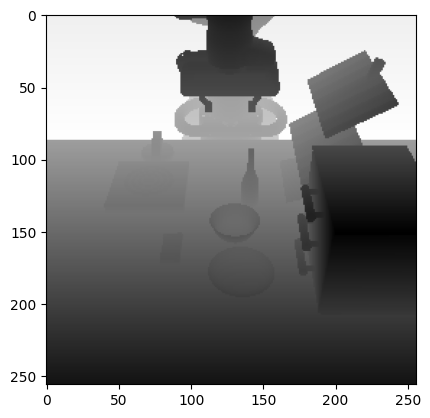

In [119]:
plt.imshow(agentview_depth[0])

In [85]:
obs.keys()

<KeysViewHDF5 ['agentview_depths', 'agentview_mask', 'agentview_rgb', 'ee_ori', 'ee_pos', 'ee_states', 'eye_in_hand_depths', 'eye_in_hand_mask', 'eye_in_hand_rgb', 'gripper_states', 'joint_states', 'mask_object_id', 'object_of_interest']>

In [164]:
d1 = obs['agentview_depths']
d2 = obs['eye_in_hand_mask']

In [167]:
d2[0]

array([[[ 5],
        [ 5],
        [ 5],
        ...,
        [ 0],
        [ 0],
        [ 0]],

       [[ 5],
        [ 5],
        [ 5],
        ...,
        [ 0],
        [ 0],
        [ 0]],

       [[ 5],
        [ 5],
        [ 5],
        ...,
        [ 0],
        [ 0],
        [ 0]],

       ...,

       [[10],
        [10],
        [10],
        ...,
        [10],
        [10],
        [10]],

       [[10],
        [10],
        [10],
        ...,
        [10],
        [10],
        [10]],

       [[10],
        [10],
        [10],
        ...,
        [10],
        [10],
        [10]]], dtype=int32)

In [145]:
# def depth_to_rgb_batch(depths: np.ndarray) -> np.ndarray:
#     """
#     Convert (T, H, W, 1) or (T, H, W) depth maps to (T, H, W, 3) normalized RGB uint8.
#     """
#     if depths.ndim == 4 and depths.shape[-1] == 1:
#         depths = depths[..., 0]  # → (T, H, W)

#     d_min = depths.min()
#     d_max = depths.max()

#     if d_max - d_min == 0:
#         norm = np.zeros_like(depths, dtype=np.uint8)
#     else:
#         norm = ((depths - d_min) / (d_max - d_min) * 255).astype(np.uint8)  # → (T, H, W)

#     rgb_depths = np.stack([norm]*3, axis=-1)  # → (T, H, W, 3)
#     return rgb_depths

def depth_to_rgb_batch(depths: np.ndarray) -> np.ndarray:
    """
    Normalize each depth map independently: (T, H, W, 1) or (T, H, W) → (T, H, W, 3) RGB uint8
    """
    if depths.ndim == 4 and depths.shape[-1] == 1:
        depths = depths[..., 0]  # (T, H, W)

    rgb_list = []
    for d in depths:
        d_min = d.min()
        d_max = d.max()
        if d_max - d_min == 0:
            norm = np.zeros_like(d, dtype=np.uint8)
        else:
            norm = ((d - d_min) / (d_max - d_min) * 255).astype(np.uint8)
        rgb_list.append(np.stack([norm] * 3, axis=-1))  # → (H, W, 3)
    
    return np.stack(rgb_list, axis=0)  # → (T, H, W, 3)


In [146]:
a = depth_to_rgb_batch(d2)
np.max(a), np.min(a), np.unique(a), a.shape

(np.uint8(255),
 np.uint8(0),
 array([  0,   2,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
         15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
         41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
         54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
         67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
         80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
         93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
        106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
        119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
        132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
        145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
        158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
        171, 172, 173

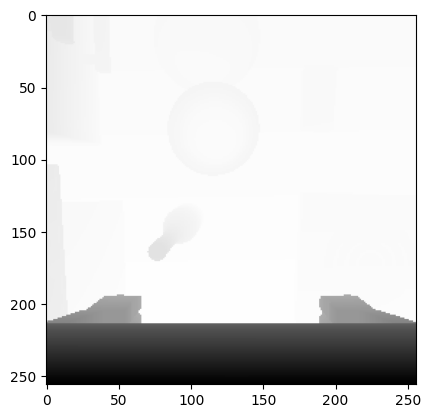

In [148]:
plt.imshow(a[5])

In [95]:
# obs['agentview_rgb'][0]

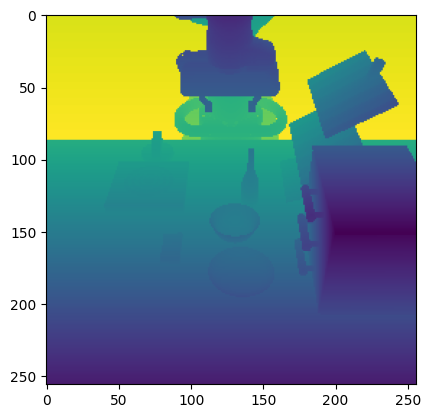

In [101]:
plt.imshow(d1[0])

In [96]:
d1[0].shape

(256, 256, 1)

[251.15654 251.15657 251.15662 ... 254.12082 254.12288 254.1235 ]
[251 252 253 254]


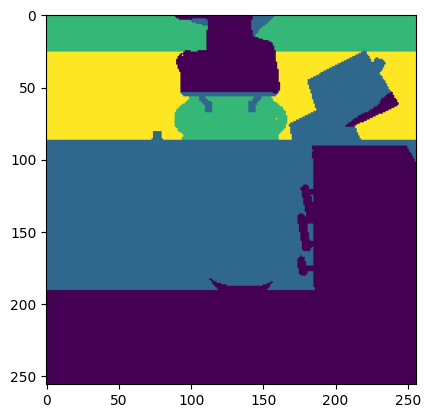

In [102]:
x = d1[0]*255
print(np.unique(x))
x = x.astype(np.uint8)
print(np.unique(x))
plt.imshow(x)

In [142]:
a = depth_to_rgb_batch(d2)
np.max(a), np.min(a), np.unique(a)

(np.uint8(255),
 np.uint8(0),
 array([  0,   5,   6,   7,   8,   9,  10,  11,  13,  14,  15,  16,  17,
         18,  19,  20,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
         32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
         45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
         58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
         97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
        110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122,
        123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
        136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148,
        149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
        162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
        175, 176, 177

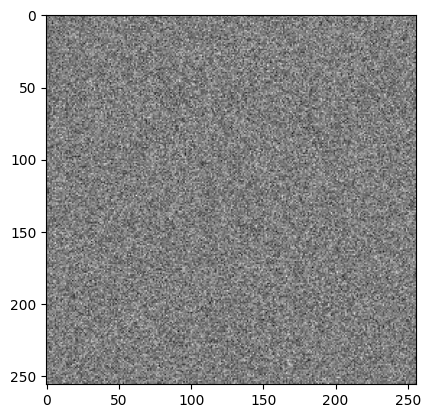

In [143]:
plt.imshow(a[0])

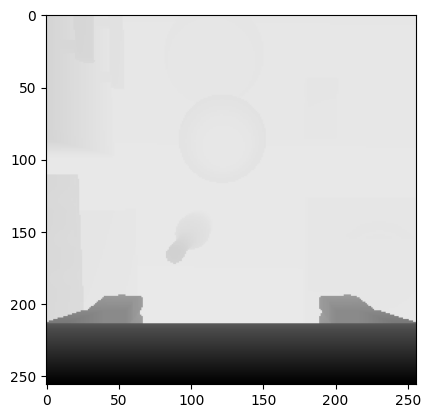

In [127]:
plt.imshow(a[0])

In [139]:

import numpy as np
import PIL.Image
import torch

def image_array_to_pil_image(image_array: np.ndarray, range_check: bool = True) -> PIL.Image.Image:
    # TODO(aliberts): handle 1 channel and 4 for depth images
    if image_array.ndim != 3:
        raise ValueError(f"The array has {image_array.ndim} dimensions, but 3 is expected for an image.")

    if image_array.shape[0] == 3:
        # Transpose from pytorch convention (C, H, W) to (H, W, C)
        image_array = image_array.transpose(1, 2, 0)

    elif image_array.shape[-1] != 3:
        raise NotImplementedError(
            f"The image has {image_array.shape[-1]} channels, but 3 is required for now."
        )

    if image_array.dtype != np.uint8:
        if range_check:
            max_ = image_array.max().item()
            min_ = image_array.min().item()
            if max_ > 1.0 or min_ < 0.0:
                raise ValueError(
                    "The image data type is float, which requires values in the range [0.0, 1.0]. "
                    f"However, the provided range is [{min_}, {max_}]. Please adjust the range or "
                    "provide a uint8 image with values in the range [0, 255]."
                )

        image_array = (image_array * 255).astype(np.uint8)
    print(image_array)

    return PIL.Image.fromarray(image_array)

In [140]:
o = image_array_to_pil_image(a[0])

[[[212 212 212]
  [213 213 213]
  [213 213 213]
  ...
  [230 230 230]
  [230 230 230]
  [230 230 230]]

 [[212 212 212]
  [213 213 213]
  [213 213 213]
  ...
  [230 230 230]
  [230 230 230]
  [230 230 230]]

 [[212 212 212]
  [213 213 213]
  [213 213 213]
  ...
  [230 230 230]
  [230 230 230]
  [230 230 230]]

 ...

 [[  4   4   4]
  [  4   4   4]
  [  4   4   4]
  ...
  [  4   4   4]
  [  4   4   4]
  [  4   4   4]]

 [[  2   2   2]
  [  2   2   2]
  [  2   2   2]
  ...
  [  2   2   2]
  [  2   2   2]
  [  2   2   2]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]]


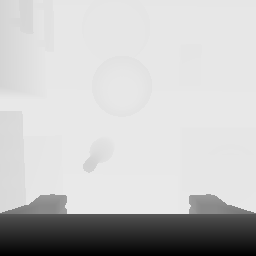

In [132]:
o

In [168]:
REPO_ID

'/mnt/lustre-grete/usr/u12045/vla/binh/lerobot/mask_depth_noops/libero_goal_noops_10/libero_goal_mask_depth_noops_lerobot'

In [169]:
dataset = LeRobotDataset(
            repo_id="HEHE",
            root=REPO_ID,
        )

NameError: name 'LeRobotDataset' is not defined